Assignement 2 - Fitting and Alignment<br>Q1 Section (a) - Total least square line fitting

Line parameters in form: ax + by + c=0
a: 0.7735616496467872
b: -0.6337210539312553
c: -3.794192210845812

Line parameters in form: y = mx + d
m: 1.2206658510839083
d: -5.9871645218487535


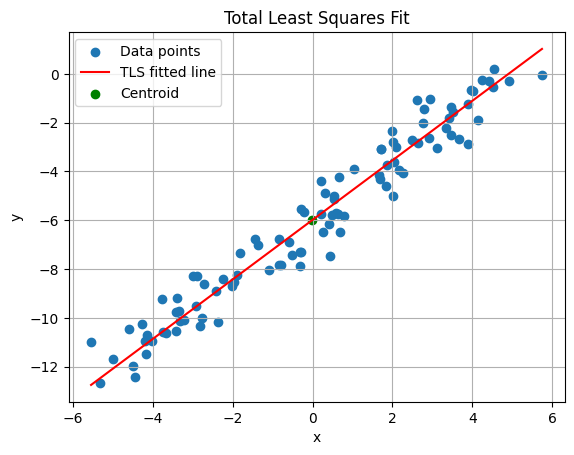

In [44]:
import numpy as np
import matplotlib.pyplot as plt

D = np.genfromtxt("lines.csv", delimiter=",", skip_header=1)

x = D[:,0]
y = D[:,3]

points = np.column_stack((x,y))

centroid = points.mean(axis=0)
points_centered = points - centroid

U, S, Vt = np.linalg.svd(points_centered)
normal = Vt[-1]
a, b = normal
c = -normal @ centroid

print("Line parameters in form: ax + by + c=0")
print("a:", a)
print("b:", b)
print("c:", c)

# Convert to solpe form for plotting
if abs(b) > 1e-6:
    m = -a / b
    d = -c / b

    x_line = np.linspace(min(x), max(x), 100)
    y_line = m * x_line + d
else:
    # Vertical line case
    x_line = np.full(100, -c / a)
    y_line = np.linspace(min(y), max(y), 100)

print("\nLine parameters in form: y = mx + d")
print("m:", m)
print("d:", d)

# plot
plt.scatter(x, y, label="Data points")
plt.plot(x_line, y_line, 'r', label="TLS fitted line")
plt.scatter(*centroid, color='green', label="Centroid")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Total Least Squares Fit")
plt.grid()

plt.show()